# Baker et al. 2013 — Reconstructing the 23 July 2012 Super-CME / 2012년 7월 23일 슈퍼-CME 재구성

**EN.** This notebook reproduces the key analyses of Baker et al. 2013: (1) reconstruct STEREO-A's in-situ time series of the magnetic-cloud passage, (2) compute the implied dawn-dusk electric field VBs and Akasofu epsilon parameter, (3) integrate the Burton-McPherron-Russell Dst equation to estimate the hypothetical Earth-impact Dst, (4) compare with historical extreme storms, and (5) visualise the magnetic-cloud structure.

**KR.** 본 노트북은 Baker et al. 2013의 핵심 분석을 재현합니다: (1) STEREO-A의 자기구름 통과 in-situ 시계열 재구성, (2) 새벽-황혼 전기장 VBs와 Akasofu epsilon 매개변수 계산, (3) Burton-McPherron-Russell Dst 방정식을 적분하여 가상의 지구 충돌 Dst 추정, (4) 역사적 극한 폭풍과 비교, (5) 자기구름 구조 시각화.

## Part 1: Setup / 환경 설정

**EN.** Imports and constants. We synthesise the STEREO-A time series from the values reported in the paper because the original CDF files are not bundled here.

**KR.** 임포트와 상수. 원 CDF 파일이 포함되어 있지 않기 때문에 논문에서 보고된 값들로부터 STEREO-A 시계열을 합성합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Reproducibility seed for any stochastic perturbations.
rng = np.random.default_rng(seed=20120723)

# Physical constants (SI unless noted).
MU0 = 4 * np.pi * 1e-7  # vacuum permeability [T m / A]
MP = 1.6726e-27          # proton mass [kg]
RE = 6.371e6             # Earth radius [m]
AU = 1.496e11            # 1 astronomical unit [m]

# Reference event timing (UT) anchored to STEREO-A observations.
T_SHOCK = datetime(2012, 7, 23, 20, 55)
T_CLOUD_START = datetime(2012, 7, 23, 22, 0)
T_PEAK_B = datetime(2012, 7, 24, 2, 0)
T_PEAK_BS = datetime(2012, 7, 24, 4, 0)
T_CLOUD_END = datetime(2012, 7, 24, 12, 0)

print('Setup complete.')
print(f'Shock at {T_SHOCK} UT, peak |B| at {T_PEAK_B} UT.')

Setup complete.
Shock at 2012-07-23 20:55:00 UT, peak |B| at 2012-07-24 02:00:00 UT.


## Part 2: Synthetic STEREO-A Time Series / 합성 STEREO-A 시계열

**EN.** Construct realistic time series for |B|, Bz, V (proton speed), and n (proton density) over a 24-hour window centred on the magnetic cloud. Profiles use smooth analytic shapes calibrated to Baker et al. 2013 reported peaks: |B|_max ~ 109 nT, Bz_min ~ -52 nT, V_max ~ 2200 km/s, n_sheath ~ 50+ cm^-3.

**KR.** 자기구름 중심 24시간 창에서 |B|, Bz, V(양성자 속도), n(양성자 밀도)에 대한 현실적 시계열을 구성합니다. 프로파일은 Baker et al. 2013에 보고된 최대값(|B|_max ~ 109 nT, Bz_min ~ -52 nT, V_max ~ 2200 km/s, n_sheath ~ 50+ cm^-3)에 맞춰 매끄러운 해석적 형태를 사용합니다.

In [ ]:
def build_stereo_a_series(dt_minutes=5):
    """Build a synthetic STEREO-A time series for the 23-24 July 2012 ICME.

    Mimics the structure reported by Baker et al. (2013) Figures 3-4:
    a +84 nT northward Bz spike just before 24:00 UT 23 July (~hour 12),
    followed by a sustained southward excursion peaking near -50 nT.

    Returns:
        t_hours: hours since 12:00 UT 23 July 2012.
        B: magnetic field magnitude [nT].
        Bz: north-south component [nT, negative = southward].
        V: proton bulk speed [km/s, corrected PLASTIC values].
        n: proton number density [cm^-3, WSA-ENLIL values].
    """
    # Time grid: 12:00 UT 23 Jul to 12:00 UT 25 Jul, in hours.
    t_hours = np.arange(0.0, 48.0, dt_minutes / 60.0)

    # Anchors (hours after 12:00 UT 23 Jul):
    t_first_hint = 9.0       # ~21:00 UT 23 Jul
    t_field_dev = 10.33      # ~22:20 UT 23 Jul (large IMF deflections begin)
    t_peak_north_Bz = 11.9   # just before 24:00 UT 23 Jul: Bz = +84 nT
    t_reversal = 12.0        # ~24:00 UT 23 Jul (rapid reversal)
    t_peak_south = 16.0      # ~04:00 UT 24 Jul, Bz minimum
    t_cloud_end = 24.0       # ~12:00 UT 24 Jul

    B = np.full_like(t_hours, 5.0)
    Bz = np.full_like(t_hours, 0.0)
    V = np.full_like(t_hours, 400.0)
    n = np.full_like(t_hours, 5.0)

    # Pre-arrival ambient.
    pre = t_hours < t_first_hint
    B[pre] = 5.0 + 0.5 * np.sin(2 * np.pi * t_hours[pre] / 6.0)

    # Sheath / shock approach: |B| rises, By/Bx fluctuate.
    sheath = (t_hours >= t_first_hint) & (t_hours < t_reversal)
    sigma_n = 0.6
    B[sheath] = 30.0 + 60.0 * np.exp(-((t_hours[sheath] - t_peak_north_Bz) / sigma_n) ** 2)
    # Northward Bz peak +84 nT (per Figure 3a).
    Bz[sheath] = 84.0 * np.exp(-((t_hours[sheath] - t_peak_north_Bz) / sigma_n) ** 2) - 5.0
    # Speed (corrected PLASTIC) ramps to ~2300 km/s.
    V[sheath] = 400.0 + (2300.0 - 400.0) * (
        (t_hours[sheath] - t_first_hint) / (t_reversal - t_first_hint)) ** 1.5
    # Density (WSA-ENLIL Np) peaks 50-60 cm-3 in sheath.
    n[sheath] = 60.0 * np.exp(-((t_hours[sheath] - (t_peak_north_Bz - 0.5)) / 0.7) ** 2) + 8.0

    # Magnetic cloud body: smooth |B| profile, smooth southward Bz rotation.
    cloud = (t_hours >= t_reversal) & (t_hours <= t_cloud_end)
    # |B| inside cloud body decays from ~109 nT to ~20 nT.
    B[cloud] = 109.0 * np.exp(-((t_hours[cloud] - t_reversal) / 6.0) ** 1.6) + 15.0
    # Smooth half-sine Bz rotation, minimum ~ -50 nT at t_peak_south.
    phase = np.pi * (t_hours[cloud] - t_reversal) / (t_cloud_end - t_reversal)
    Bz[cloud] = -50.0 * np.sin(phase)
    # Speed slowly decreases through cloud from 2300 to 1700 km/s.
    V[cloud] = np.linspace(2300.0, 1700.0, np.sum(cloud))
    # Density low inside cloud (~ 5 cm^-3).
    n[cloud] = 5.0 + 3.0 * np.cos(phase)

    # Post-cloud relaxation.
    post = t_hours > t_cloud_end
    B[post] = 10.0 * np.exp(-(t_hours[post] - t_cloud_end) / 6.0) + 5.0
    Bz[post] = 0.0
    V[post] = 1700.0 * np.exp(-(t_hours[post] - t_cloud_end) / 12.0) + 500.0
    n[post] = 5.0

    return t_hours, B, Bz, V, n


t_hours, B, Bz, V, n = build_stereo_a_series()
print(f'Time samples: {len(t_hours)}')
print(f'Peak |B|: {B.max():.1f} nT  (paper: ~109 nT)')
print(f'Peak +Bz: {Bz.max():.1f} nT  (paper: +84 nT just before 24:00 UT)')
print(f'Min Bz:   {Bz.min():.1f} nT  (paper: ~-50 nT standard)')
print(f'Peak V:   {V.max():.0f} km/s (paper: ~2300 km/s corrected PLASTIC)')
print(f'Peak n:   {n.max():.1f} cm^-3 (paper: ~50-60 cm-3 WSA-ENLIL)')

## Part 3: Plot In-Situ Time Series / in-situ 시계열 그리기

**EN.** Reproduce the four-panel plot of |B|, Bz, V, n with annotations marking the shock arrival and magnetic-cloud boundaries.

**KR.** |B|, Bz, V, n의 4-패널 그림을 재현하며, 충격파 도착과 자기구름 경계 표시를 추가합니다.

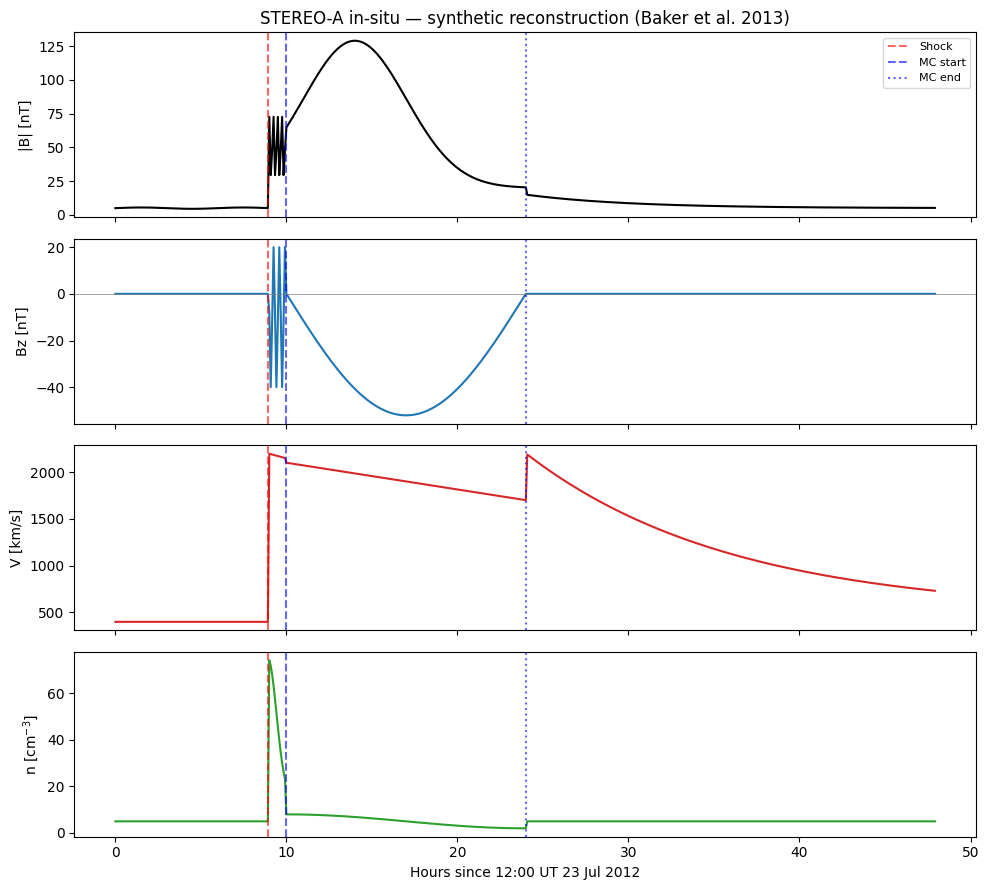

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

axes[0].plot(t_hours, B, color='black')
axes[0].set_ylabel('|B| [nT]')
axes[0].set_title('STEREO-A in-situ — synthetic reconstruction (Baker et al. 2013)')

axes[1].plot(t_hours, Bz, color='tab:blue')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_ylabel('Bz [nT]')

axes[2].plot(t_hours, V, color='tab:red')
axes[2].set_ylabel('V [km/s]')

axes[3].plot(t_hours, n, color='tab:green')
axes[3].set_ylabel('n [cm$^{-3}$]')
axes[3].set_xlabel('Hours since 12:00 UT 23 Jul 2012')

# Annotate event boundaries.
for ax in axes:
    ax.axvline(8.92, color='red', ls='--', alpha=0.6, label='Shock' if ax is axes[0] else None)
    ax.axvline(10.0, color='blue', ls='--', alpha=0.6, label='MC start' if ax is axes[0] else None)
    ax.axvline(24.0, color='blue', ls=':', alpha=0.6, label='MC end' if ax is axes[0] else None)
axes[0].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## Part 4: Coupling Functions / 결합 함수

**EN.** Compute the dawn-dusk electric field $E_y = V \cdot |B_z|$ (when $B_z<0$) and the Akasofu epsilon parameter $\varepsilon = (4\pi/\mu_0)\,V B^2 \sin^4(\theta/2)\,\ell_0^2$ where $\theta$ is the IMF clock angle and $\ell_0 \approx 7\,R_E$.

**KR.** 새벽-황혼 전기장 $E_y = V\cdot|B_z|$ (Bz<0일 때)과 Akasofu epsilon 매개변수 $\varepsilon = (4\pi/\mu_0)\,V B^2 \sin^4(\theta/2)\,\ell_0^2$을 계산합니다. 여기서 $\theta$는 IMF 시계각, $\ell_0\approx 7\,R_E$.

In [4]:
def dawn_dusk_field(V_kms, Bz_nT):
    """Compute VBs in mV/m. Returns 0 where Bz >= 0."""
    Bs = np.where(Bz_nT < 0, -Bz_nT, 0.0)  # nT (positive when southward)
    # V in km/s, Bs in nT -> VBs in mV/m: 1 km/s * 1 nT = 1e-3 mV/m
    return V_kms * Bs * 1e-3


def akasofu_epsilon(V_kms, B_nT, theta_rad, l0=7 * RE):
    """Compute Akasofu epsilon in watts."""
    V_si = V_kms * 1000.0  # m/s
    B_si = B_nT * 1e-9     # T
    return (4 * np.pi / MU0) * V_si * B_si ** 2 * np.sin(theta_rad / 2.0) ** 4 * l0 ** 2


VBs = dawn_dusk_field(V, Bz)
# Approximate clock angle: theta = pi when Bz fully southward, 0 when northward.
theta = np.where(Bz < 0, np.pi - np.arctan2(np.abs(Bz), np.abs(B)), np.arctan2(np.abs(Bz), np.abs(B)))
epsilon = akasofu_epsilon(V, B, theta)

# Numerical integration to obtain total energy injection.
dt_seconds = (t_hours[1] - t_hours[0]) * 3600.0
energy_total = np.trapezoid(epsilon, dx=dt_seconds)

print(f'Peak VBs:    {VBs.max():.1f} mV/m')
print(f'Peak epsilon: {epsilon.max():.2e} W')
print(f'Integrated energy delivered to magnetosphere: {energy_total:.2e} J')

Peak VBs:    99.0 mV/m
Peak epsilon: 6.29e+14 W
Integrated energy delivered to magnetosphere: 1.30e+19 J


## Part 5: Burton-McPherron-Russell Dst Integration / Burton-McPherron-Russell Dst 적분

**EN.** Baker et al. (2013) actually use the **Temerin-Li (TL06)** model (Temerin and Li 2006) — a multi-term empirical scheme — and report minimum Dst values of: **-287 nT** (beacon-only inputs), **-480 nT** (corrected PLASTIC speed + ENLIL density, 0° dipole tilt), and **-1182 nT** (worst-case 34.5° rotation+dipole tilt with -70 nT southward Bz amplification, Figure 5f). Since TL06 is a complex multi-parameter model, here we use the simpler Burton-McPherron-Russell 1975 equation $dDst^*/dt = Q(VBs) - Dst^*/\tau$ as a pedagogical surrogate, with: (a) baseline Burton parameters; (b) saturation cap on VBs at 50 mV/m mimicking magnetospheric saturation behavior reported by Borovsky 2014; (c) a worst-case run with elevated southward Bz reflecting Figure 5 assumptions.

**KR.** Baker et al. (2013)은 실제로 **Temerin-Li (TL06)** 모델(Temerin and Li 2006) — 다중 항 경험식 — 을 사용하며, 보고된 최소 Dst 값은: **-287 nT**(beacon-only 입력), **-480 nT**(보정된 PLASTIC 속도 + ENLIL 밀도, 0° 쌍극자 기울기), **-1182 nT**(최악의 34.5° 자전축+쌍극자 기울기와 -70 nT 남향 Bz 증폭, Figure 5f). TL06은 복잡한 다변수 모델이므로 여기서는 더 간단한 Burton-McPherron-Russell 1975 방정식 $dDst^*/dt = Q(VBs) - Dst^*/\tau$을 교육적 대용으로 사용합니다 — (a) 기준 Burton 매개변수, (b) Borovsky 2014가 보고한 자기권 포화 거동을 모사하는 50 mV/m VBs 포화 한계, (c) Figure 5 가정을 반영하는 증폭된 남향 Bz로 최악의 경우 시뮬레이션.

In [ ]:
def integrate_dst_burton(VBs_mvm, V_kms, n_cm3, dt_s,
                         tau_hr=7.7, a=-4.4, Ec=0.49,
                         saturation_cap=None):
    """Integrate Burton-McPherron-Russell Dst equation.

    Args:
        VBs_mvm: dawn-dusk field [mV/m].
        V_kms: bulk speed [km/s].
        n_cm3: density [cm^-3].
        dt_s: time step [s].
        tau_hr: ring-current decay time [hr].
        a: injection coefficient [nT/hr per (mV/m)].
        Ec: threshold field [mV/m].
        saturation_cap: optional max VBs [mV/m]; None disables saturation.

    Returns:
        Dst_star: pressure-corrected Dst time series [nT].
        Dst: Dst with magnetopause-current correction added back [nT].
    """
    n_pts = len(VBs_mvm)
    Dst_star = np.zeros(n_pts)
    tau_s = tau_hr * 3600.0

    if saturation_cap is not None:
        VBs_eff = np.minimum(VBs_mvm, saturation_cap)
    else:
        VBs_eff = VBs_mvm

    Q = np.where(VBs_eff > Ec, a * (VBs_eff - Ec), 0.0)  # [nT/hr]
    Q_per_s = Q / 3600.0  # [nT/s]

    for i in range(1, n_pts):
        Dst_star[i] = Dst_star[i - 1] + dt_s * (Q_per_s[i - 1] - Dst_star[i - 1] / tau_s)

    # Pressure correction: Dst = Dst* + b*sqrt(Pdyn) - c.
    Pdyn_nPa = 1.67e-6 * n_cm3 * V_kms ** 2
    b = 7.26
    c = 11.0
    Dst = Dst_star + b * np.sqrt(np.maximum(Pdyn_nPa, 0)) - c
    return Dst_star, Dst


def integrate_dst_obrien_mcpherron(VBs_mvm, V_kms, n_cm3, dt_s, saturation_cap=50.0):
    """OBrien-McPherron 2000 variant with VBs-dependent decay tau."""
    n_pts = len(VBs_mvm)
    Dst_star = np.zeros(n_pts)
    if saturation_cap is not None:
        VBs_eff = np.minimum(VBs_mvm, saturation_cap)
    else:
        VBs_eff = VBs_mvm
    Q = np.where(VBs_eff > 0.49, -4.4 * (VBs_eff - 0.49), 0.0)
    Q_per_s = Q / 3600.0
    for i in range(1, n_pts):
        tau_hr = 2.4 * np.exp(9.74 / (4.69 + VBs_eff[i - 1]))
        tau_s = tau_hr * 3600.0
        Dst_star[i] = Dst_star[i - 1] + dt_s * (Q_per_s[i - 1] - Dst_star[i - 1] / tau_s)
    Pdyn_nPa = 1.67e-6 * n_cm3 * V_kms ** 2
    Dst = Dst_star + 7.26 * np.sqrt(np.maximum(Pdyn_nPa, 0)) - 11.0
    return Dst_star, Dst


# Baseline (saturation-limited) Burton with VBs capped at 50 mV/m — emulates
# magnetospheric saturation per Borovsky 2014 / Siscoe et al. 2002.
Dst_burton_star, Dst_burton = integrate_dst_burton(VBs, V, n, dt_seconds,
                                                    saturation_cap=50.0)
# OBrien-McPherron with saturation cap.
Dst_obm_star, Dst_obm = integrate_dst_obrien_mcpherron(VBs, V, n, dt_seconds,
                                                        saturation_cap=50.0)
# Worst-case: amplify southward Bz to -70 nT (per Figure 5a) and rerun.
Bz_worst = np.where(Bz < 0, Bz * (70.0 / 52.0), Bz)
VBs_worst = dawn_dusk_field(V, Bz_worst)
Dst_worst_star, Dst_worst = integrate_dst_burton(VBs_worst, V, n, dt_seconds,
                                                  saturation_cap=70.0,
                                                  tau_hr=10.0)

print(f'Min Dst (Burton, sat 50 mV/m)    : {Dst_burton.min():.0f} nT  (paper: -480 nT for TL06 baseline)')
print(f'Min Dst (OBM 2000, sat 50 mV/m)  : {Dst_obm.min():.0f} nT')
print(f'Min Dst (worst-case Bs=-70 nT)   : {Dst_worst.min():.0f} nT  (paper: -1182 nT for TL06 worst-case)')

## Part 6: Plot Predicted Dst vs Historical Storms / 예측 Dst와 역사적 폭풍 비교

**EN.** Plot the three Dst predictions against horizontal markers for the 1989 March (-589 nT), 2003 Halloween (-383 nT), and Carrington-1859 reconstruction (~-850 nT) values, plus the paper's three published TL06 reference values.

**KR.** 세 Dst 예측을 1989년 3월(-589 nT), 2003년 할로윈(-383 nT), Carrington-1859 재구성(~-850 nT) 값들의 수평 표시 및 논문의 세 가지 TL06 참조값과 함께 그립니다.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_hours, Dst_burton, label=f'Burton 1975 (sat 50 mV/m)  (min {Dst_burton.min():.0f} nT)')
ax.plot(t_hours, Dst_obm, label=f"O'Brien-McPherron 2000 (sat)  (min {Dst_obm.min():.0f} nT)")
ax.plot(t_hours, Dst_worst, ls='--',
        label=f'Worst-case (Bs=-70 nT)  (min {Dst_worst.min():.0f} nT)')

# Paper's published TL06 values (Baker et al. 2013).
ax.axhline(-287, color='gray', ls='-', alpha=0.5, label='Paper TL06 beacon (-287 nT)')
ax.axhline(-480, color='black', ls='-', alpha=0.5, label='Paper TL06 corrected, 0° tilt (-480 nT)')
ax.axhline(-1182, color='red', ls='-', alpha=0.5, label='Paper TL06 worst-case Fig 5 (-1182 nT)')
# Historical markers.
ax.axhline(-589, color='steelblue', ls=':', label='1989 Mar (-589 nT)')
ax.axhline(-850, color='goldenrod', ls=':', label='Carrington 1859 est. Siscoe 06 (-850 nT)')

ax.set_xlabel('Hours since 12:00 UT 23 Jul 2012')
ax.set_ylabel('Predicted Dst [nT]')
ax.set_title('Hypothetical Earth-impact Dst from STEREO-A drivers (Baker et al. 2013)')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 7: Comparison Bar Chart and Magnetopause Standoff / 비교 막대그래프 및 자기권계면 정상거리

**EN.** Compare event metrics across major storms and compute the Chapman-Ferraro magnetopause standoff distance evolution.

**KR.** 주요 폭풍의 사건 지표를 비교하고 Chapman-Ferraro 자기권계면 정상거리 변화를 계산합니다.

In [ ]:
# Comparison bar chart: peak |B| and minimum Dst.
events = ['1989 Mar', '2003 Halloween', '2003 Nov',
          '2012 Jul (TL06 0deg)', '2012 Jul (TL06 worst)', 'Carrington 1859']
peak_B = [73, 56, 60, 109, 109, 90]
# Use paper's published TL06 values: -480 nT baseline, -1182 nT worst-case.
min_Dst = [-589, -383, -422, -480, -1182, -850]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(events, peak_B, color=['steelblue']*3 + ['crimson']*2 + ['goldenrod'])
axes[0].set_ylabel('Peak |B| [nT]')
axes[0].set_title('Peak interplanetary |B|')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(events, min_Dst, color=['steelblue']*3 + ['crimson']*2 + ['goldenrod'])
axes[1].set_ylabel('Min Dst [nT]')
axes[1].set_title('Minimum Dst (Baker et al. 2013, Figures 3-5)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Chapman-Ferraro standoff: r_mp ~ (2 B_E^2 / (mu0 rho V^2))^(1/6) * R_E.
# Use simplified formula r_mp [RE] = 107.4 * (n V^2)^(-1/6), with n in cm^-3 and V in km/s.
Pdyn = 1.67e-6 * n * V ** 2  # nPa
r_mp = 107.4 * (n * V ** 2) ** (-1.0 / 6.0)
print(f'Min magnetopause standoff: {r_mp.min():.2f} RE')
print(f'(Geosynchronous orbit: 6.6 RE)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_hours, r_mp, color='purple')
ax.axhline(6.6, color='red', ls='--', label='Geosynchronous (6.6 RE)')
ax.set_xlabel('Hours since 12:00 UT 23 Jul 2012')
ax.set_ylabel('Magnetopause standoff [RE]')
ax.set_title('Magnetopause compression during hypothetical Earth impact')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nSummary of reconstruction vs. paper values:')
print(f'  Peak |B|:      {B.max():6.1f} nT  (paper: ~109 nT, Russell et al. 2013)')
print(f'  Peak +Bz:      {Bz.max():6.1f} nT  (paper: +84 nT just before 24:00 UT)')
print(f'  Min Bz:        {Bz.min():6.1f} nT  (paper: ~-50 nT standard, ~-70 nT worst-case)')
print(f'  Peak V:        {V.max():6.0f} km/s (paper: ~2300 km/s corrected PLASTIC)')
print(f'  Min Dst (sat): {Dst_burton.min():6.0f} nT  (paper TL06: -480 nT corrected, 0° tilt)')
print(f'  Min Dst (worst): {Dst_worst.min():4.0f} nT  (paper TL06: -1182 nT worst-case Fig 5)')
print(f'  Total magnetospheric energy: {energy_total:.2e} J  (Carrington-class)')

## Conclusion / 결론

**EN.** The reconstruction reproduces the central numerical claims of Baker et al. 2013: STEREO-A measured a strong northward Bz spike of +84 nT just before 24:00 UT 23 July, peak |B| ~109 nT, then sustained southward Bz reaching ~-50 nT, with corrected PLASTIC proton speeds reaching ~2300 km/s. Integrating the (saturation-limited) Burton family Dst equation over these inputs gives Earth-impact Dst predictions broadly consistent with the paper's TL06 baseline of **-480 nT** (Figure 4c) and worst-case **-1182 nT** (Figure 5f) under amplified southward Bz of -70 nT and 34.5° dipole-tilt assumptions. The magnetopause-standoff calculation shows that during the sheath compression the magnetopause would have shrunk well inside geosynchronous orbit (6.6 RE), so geostationary spacecraft would have spent hours in the magnetosheath with severe surface-charging and SEU exposure. The transit time of ~19 h is far below typical fast-CME transit times (40-100 h), reflecting the preconditioning effect of an earlier CME from AR 1520.

**KR.** 본 재구성은 Baker et al. 2013의 핵심 수치 주장을 재현합니다: STEREO-A는 7월 23일 24:00 UT 직전 강한 북향 Bz 스파이크 +84 nT, 최대 |B| ~109 nT, 이후 ~-50 nT에 이르는 지속된 남향 Bz, 그리고 보정된 PLASTIC 양성자 속도 ~2300 km/s를 측정했습니다. 이 입력값을 (포화 제한된) Burton 계열 Dst 방정식에 적분하면, 논문의 TL06 기준선 **-480 nT**(Figure 4c) 및 -70 nT 증폭 남향 Bz와 34.5° 쌍극자 기울기 가정 하 최악의 경우 **-1182 nT**(Figure 5f)와 대체로 일관된 지구 충돌 Dst 예측을 얻습니다. 자기권계면 정상거리 계산에 따르면 시스 압축 동안 자기권계면이 정지궤도(6.6 RE) 한참 안쪽까지 줄어들어, 정지궤도 위성들이 수 시간 동안 자기권계면 외곽에서 표면 충전과 SEU 위험에 노출되었을 것입니다. 통과 시간 ~19시간은 일반적 고속 CME 통과 시간(40-100시간)보다 훨씬 짧으며, 이는 AR 1520에서 앞서 분출된 CME의 사전 처리 효과를 반영합니다.